#Linear Regression (Simple & Multiple) on Housing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("Housing.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())

# Convert yes/no binary categorical columns to 1/0
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating",
               "airconditioning", "prefarea"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

# One-hot encode the multi-category column (furnishingstatus)
df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)

print("\nPreprocessed data:\n", df.head())

Shape: (545, 13)

First 5 rows:
       price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Missing values:
 price               0
area                0
bedr

In [4]:
X_simple = df[["area"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train, y_train)
y_pred_simple = simple_model.predict(X_test)

mae_s = mean_absolute_error(y_test, y_pred_simple)
mse_s = mean_squared_error(y_test, y_pred_simple)
r2_s = r2_score(y_test, y_pred_simple)

print("\n===== SIMPLE LINEAR REGRESSION (area -> price) =====")
print(f"Intercept: {simple_model.intercept_:.2f}")
print(f"Coefficient (area): {simple_model.coef_[0]:.2f}")
print(f"MAE: {mae_s:,.2f}")
print(f"MSE: {mse_s:,.2f}")
print(f"R^2: {r2_s:.4f}")


===== SIMPLE LINEAR REGRESSION (area -> price) =====
Intercept: 2512254.26
Coefficient (area): 425.73
MAE: 1,474,748.13
MSE: 3,675,286,604,768.19
R^2: 0.2729


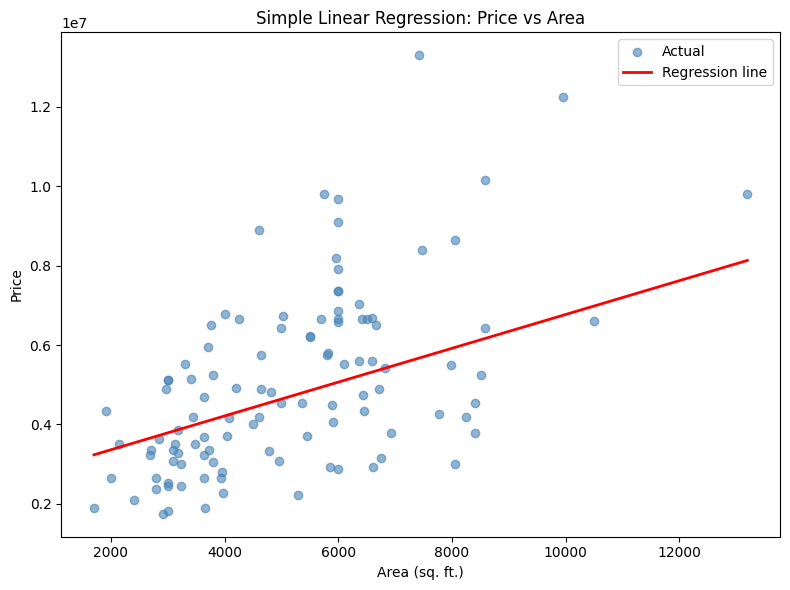

In [8]:
 # Plot regression line
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color="steelblue", alpha=0.6, label="Actual")
# sort for a clean line
sort_idx = X_test["area"].values.argsort()
plt.plot(X_test["area"].values[sort_idx], y_pred_simple[sort_idx],
          color="red", linewidth=2, label="Regression line")
plt.xlabel("Area (sq. ft.)")
plt.ylabel("Price")
plt.title("Simple Linear Regression: Price vs Area")
plt.legend()
plt.tight_layout()
plt.show()
plt.close()


===== MULTIPLE LINEAR REGRESSION (all features -> price) =====
Intercept: 260032.36
MAE: 970,043.40
MSE: 1,754,318,687,330.66
R^2: 0.6529

Feature coefficients (sorted by impact):
                         Feature   Coefficient
                      bathrooms  1.094445e+06
                airconditioning  7.914267e+05
                hotwaterheating  6.846499e+05
                       prefarea  6.298906e+05
   furnishingstatus_unfurnished -4.136451e+05
                        stories  4.074766e+05
                       basement  3.902512e+05
                       mainroad  3.679199e+05
                      guestroom  2.316100e+05
                        parking  2.248419e+05
furnishingstatus_semi-furnished -1.268818e+05
                       bedrooms  7.677870e+04
                           area  2.359688e+02


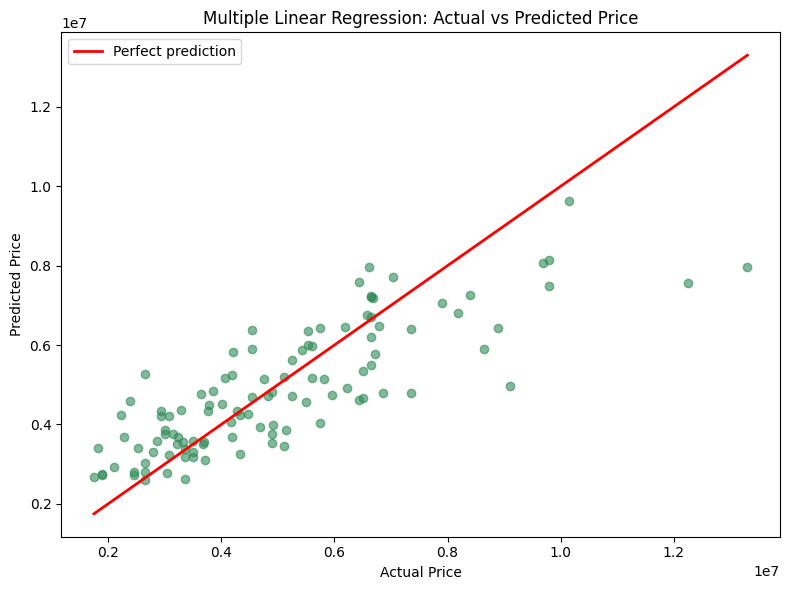

In [9]:
X_multi = df.drop("price", axis=1)
y = df["price"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)
y_pred_multi = multi_model.predict(X_test_m)

mae_m = mean_absolute_error(y_test_m, y_pred_multi)
mse_m = mean_squared_error(y_test_m, y_pred_multi)
r2_m = r2_score(y_test_m, y_pred_multi)

print("\n===== MULTIPLE LINEAR REGRESSION (all features -> price) =====")
print(f"Intercept: {multi_model.intercept_:.2f}")
print(f"MAE: {mae_m:,.2f}")
print(f"MSE: {mse_m:,.2f}")
print(f"R^2: {r2_m:.4f}")

# Coefficient interpretation table
coef_df = pd.DataFrame({
    "Feature": X_multi.columns,
    "Coefficient": multi_model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("\nFeature coefficients (sorted by impact):\n", coef_df.to_string(index=False))

# Plot: Actual vs Predicted for multiple regression
plt.figure(figsize=(8, 6))
plt.scatter(y_test_m, y_pred_multi, color="seagreen", alpha=0.6)
lims = [min(y_test_m.min(), y_pred_multi.min()), max(y_test_m.max(), y_pred_multi.max())]
plt.plot(lims, lims, color="red", linewidth=2, label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Multiple Linear Regression: Actual vs Predicted Price")
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

In [10]:
print("\n===== INTERPRETATION =====")
print(f"Simple model: each extra sq.ft of area increases predicted price by "
      f"~{simple_model.coef_[0]:,.2f} (holding nothing else constant).")
top_feature = coef_df.iloc[0]
print(f"Multiple model: '{top_feature['Feature']}' has the largest effect on price, "
      f"with a coefficient of {top_feature['Coefficient']:,.2f}.")
print("Positive coefficients increase price; negative coefficients decrease price, "
      "holding all other features constant.")


===== INTERPRETATION =====
Simple model: each extra sq.ft of area increases predicted price by ~425.73 (holding nothing else constant).
Multiple model: 'bathrooms' has the largest effect on price, with a coefficient of 1,094,444.79.
Positive coefficients increase price; negative coefficients decrease price, holding all other features constant.
